# How the Core-8 judges actually behave

Every judge on the panel was asked the same 100 RewardBench 2 comparisons under
seven evaluation contexts, and answered with a distribution over
(A better, B better, tie) read off the continuation log-likelihoods. No sampling,
no free-text parsing.

This notebook establishes two things before any compression claim is made:

1. the scoring pipeline produces real signal rather than noise or a constant; and
2. the judges fail in *context-dependent* ways, which is the entire reason the
   selection objective takes a maximum over contexts instead of an average.

All probabilities below are already orientation-corrected, so a judge that reads
content rather than position should look the same before and after a swap.

> **Which panel is this?** J02, J05, J08, J10, J12, J14, J16, J20 — the **Core-8
> smoke panel** of execution plan §10.3, on the 100 stratified items the plan
> specifies. It is the pipeline-validation panel that must pass quality gates
> G0–G2 before formal inference on the 20-model **Core-20** panel (§10) begins.
> Notebook 03 explains what this means for the compression claim.

**Reading order:** 01 (this notebook, does the measurement work at all) ->
02 (Claim C1, why selection must be joint) -> 03 (Claim C2, how far compression
actually gets).

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)

from epcrc.panel import PANELS, scores_dir

# Set EPCRC_PANEL=core20 to run this against the formal panel.
PANEL = os.environ.get("EPCRC_PANEL", "core8")
SCORES = scores_dir(PANEL)
FIGS = os.path.join(ROOT, "results", "figures")
os.makedirs(FIGS, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

# The judge list comes from the registry, not from the filenames on disk.  The
# cache directory is shared with the G0-G2 gate runs, which write blocks under
# their own ids (`G1__I0_clean.json`), and a gate block covers one context rather
# than all seven -- scraping the directory therefore builds a ragged grid and the
# first indexing of it raises.  Restricting to the registry also means a judge
# that was never scored is reported as missing instead of silently absent.
blocks = {}
for name in sorted(os.listdir(SCORES)):
    if not name.endswith(".json"):
        continue
    judge, context = name[:-5].split("__")
    if judge not in PANELS[PANEL]:
        continue
    with open(os.path.join(SCORES, name)) as handle:
        blocks[(judge, context)] = json.load(handle)

judges = sorted({j for j, _ in blocks})
contexts = sorted({c for _, c in blocks})
models = {j: blocks[(j, contexts[0])]["model_id"] for j in judges}

missing = sorted(set(PANELS[PANEL]) - set(judges))
print(f"panel {PANEL}: {len(judges)} of {len(PANELS[PANEL])} judges x {len(contexts)} contexts")
if missing:
    print(f"NOT SCORED (deviation from plan section 10): {', '.join(missing)}")
for j in judges:
    print(f"  {j}  {models[j]}")

panel core20: 19 of 20 judges x 7 contexts
NOT SCORED (deviation from plan section 10): J07
  J01  Qwen/Qwen2.5-3B-Instruct
  J02  Qwen/Qwen2.5-7B-Instruct
  J03  Qwen/Qwen2.5-14B-Instruct
  J04  Qwen/Qwen3-4B
  J05  Qwen/Qwen3-8B
  J06  Qwen/Qwen3-14B
  J08  meta-llama/Llama-3.1-8B-Instruct
  J09  google/gemma-3-4b-it
  J10  google/gemma-3-12b-it
  J11  microsoft/Phi-4-mini-instruct
  J12  microsoft/phi-4
  J13  microsoft/Phi-3.5-mini-instruct
  J14  mistralai/Mistral-7B-Instruct-v0.3
  J15  mistralai/Mistral-Nemo-Instruct-2407
  J16  ibm-granite/granite-3.3-8b-instruct
  J17  tiiuae/Falcon3-7B-Instruct
  J18  tiiuae/Falcon3-10B-Instruct
  J19  CohereLabs/aya-expanse-8b
  J20  allenai/OLMo-2-1124-7B-Instruct


## 1. The pipeline produces signal, not a constant

Two sanity numbers. `binary_accuracy_non_tie` is agreement with the human label
on items that have a true winner, and `mean_max_probability` is how confident the
judge is. A broken scorer would sit at chance with a near-uniform distribution.

binary accuracy range: 0.483 - 0.789
confidence range:      0.577 - 0.980


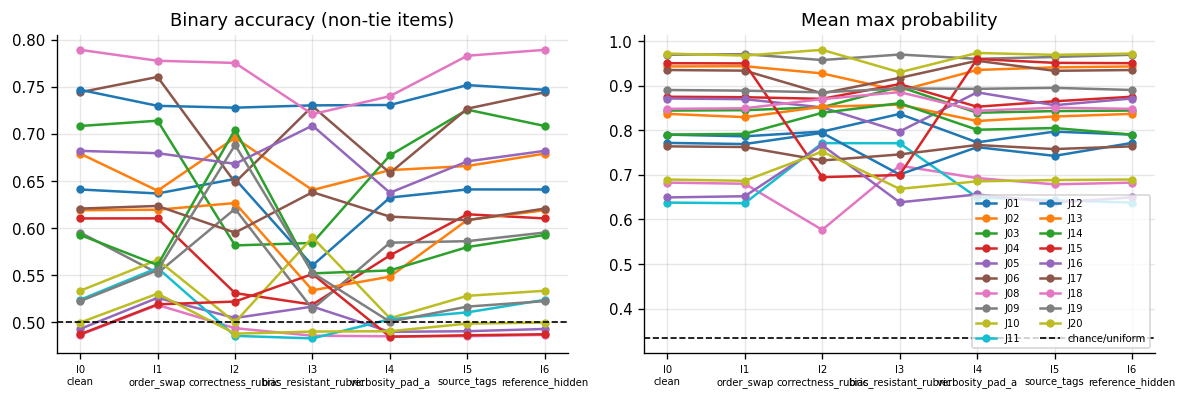

In [2]:
def grid(key):
    return np.array([[blocks[(j, c)]["accuracy"][key] for c in contexts] for j in judges])

binary = grid("binary_accuracy_non_tie")
conf = grid("mean_max_probability")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, data, title, ref in (
    (axes[0], binary, "Binary accuracy (non-tie items)", 0.5),
    (axes[1], conf, "Mean max probability", 1 / 3),
):
    for i, j in enumerate(judges):
        ax.plot(range(len(contexts)), data[i], marker="o", ms=4, label=j)
    ax.axhline(ref, color="k", ls="--", lw=1, label="chance/uniform")
    ax.set_xticks(range(len(contexts)))
    ax.set_xticklabels([c.replace("_", "\n", 1) for c in contexts], fontsize=6)
    ax.set_title(title)
axes[1].legend(fontsize=6, ncol=2, loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "judge_signal.png"), bbox_inches="tight")

print(f"binary accuracy range: {binary.min():.3f} - {binary.max():.3f}")
print(f"confidence range:      {conf.min():.3f} - {conf.max():.3f}")

Every judge is above chance on the binary decision and far more confident than
uniform, so the label extraction is doing its job.

## 2. Finding 1 — judges answer by position, not by content

`position_bias_a_rate` is how often the judge picks canonical response A. The
orientation correction has already undone the swap, so a content-driven judge
should give the *same* rate on `I0_clean` and `I1_order_swap`. A point far from
the diagonal is a judge that is really choosing a slot.

judge   clean   swapped   |shift|
J08      0.00    1.00    0.99
J15      0.00    0.99    0.99
J20      0.03    0.95    0.92
J05      0.01    0.91    0.90
J10      0.06    0.91    0.85
J11      0.01    0.86    0.85
J02      0.79    0.19    0.61
J09      0.73    0.16    0.57
J19      0.03    0.58    0.56
J12      0.63    0.24    0.39
J06      0.31    0.66    0.35
J16      0.48    0.23    0.25
J14      0.23    0.03    0.20
J03      0.37    0.56    0.20
J13      0.19    0.38    0.19
J01      0.17    0.34    0.17
J04      0.21    0.36    0.15
J17      0.41    0.54    0.14
J18      0.28    0.32    0.04


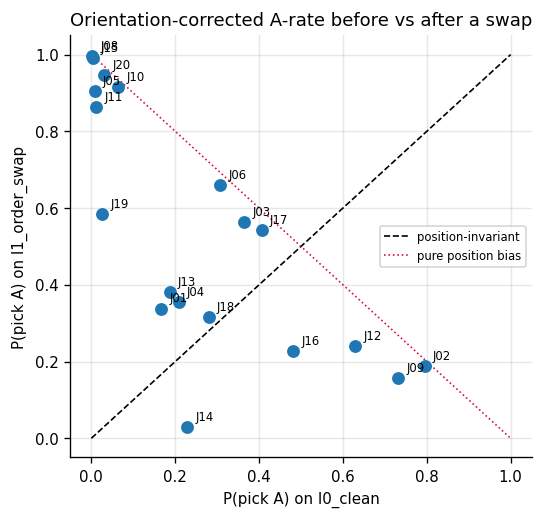

In [3]:
clean = np.array([blocks[(j, "I0_clean")]["accuracy"]["position_bias_a_rate"] for j in judges])
swapped = np.array([blocks[(j, "I1_order_swap")]["accuracy"]["position_bias_a_rate"] for j in judges])

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="position-invariant")
ax.plot([0, 1], [1, 0], color="crimson", ls=":", lw=1, label="pure position bias")
ax.scatter(clean, swapped, s=45, zorder=3)
for j, x, y in zip(judges, clean, swapped):
    ax.annotate(j, (x, y), textcoords="offset points", xytext=(5, 4), fontsize=7)
ax.set_xlabel("P(pick A) on I0_clean")
ax.set_ylabel("P(pick A) on I1_order_swap")
ax.set_title("Orientation-corrected A-rate before vs after a swap")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "position_bias.png"), bbox_inches="tight")

print("judge   clean   swapped   |shift|")
for j, x, y in sorted(zip(judges, clean, swapped), key=lambda t: -abs(t[1] - t[2])):
    print(f"{j:<7} {x:5.2f}   {y:5.2f}    {abs(x - y):.2f}")

The judges sit near the **anti-diagonal**, not the diagonal. They are largely
answering by slot. This is a real, measurable failure that is invisible if you
only ever evaluate on clean items, and it is the empirical justification for the
worst-context objective (claim C4).

## 3. Finding 2 — one judge is a degenerate tie-sayer

The gold tie rate is fixed by the data. A judge whose predicted tie rate is far
above it is not judging badly, it is answering a different question.

most tie-happy judge: J14 (mistralai/Mistral-7B-Instruct-v0.3)
  predicted tie rate 0.77 vs gold 0.03
  three-class accuracy 0.16
  but binary accuracy  0.59  <- it can still rank


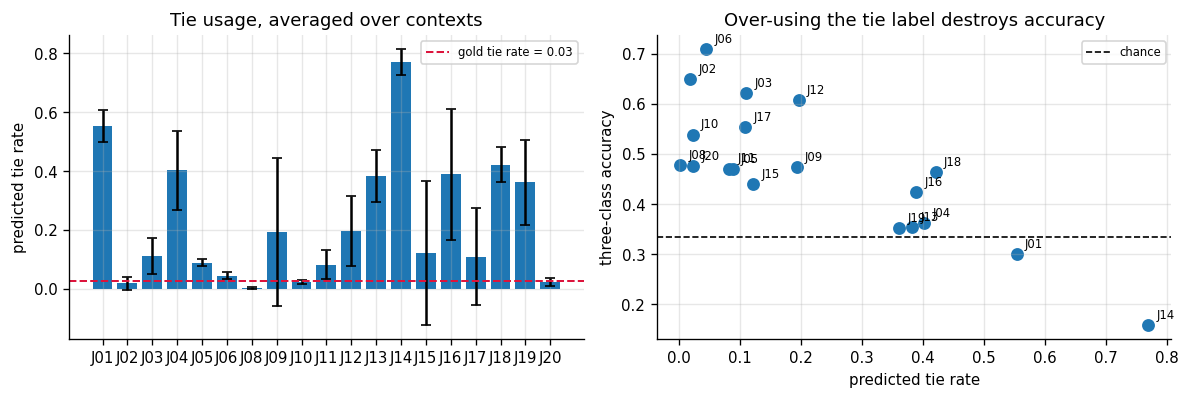

In [4]:
pred_tie = grid("predicted_tie_rate")
gold_tie = grid("gold_tie_rate")[0, 0]
three = grid("three_class_accuracy")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
x = np.arange(len(judges))
axes[0].bar(x, pred_tie.mean(axis=1), yerr=pred_tie.std(axis=1), capsize=3)
axes[0].axhline(gold_tie, color="crimson", ls="--", lw=1.2, label=f"gold tie rate = {gold_tie:.2f}")
axes[0].set_xticks(x); axes[0].set_xticklabels(judges)
axes[0].set_ylabel("predicted tie rate"); axes[0].legend(fontsize=7)
axes[0].set_title("Tie usage, averaged over contexts")

axes[1].scatter(pred_tie.mean(axis=1), three.mean(axis=1), s=45)
for j, xx, yy in zip(judges, pred_tie.mean(axis=1), three.mean(axis=1)):
    axes[1].annotate(j, (xx, yy), textcoords="offset points", xytext=(5, 4), fontsize=7)
axes[1].axhline(1 / 3, color="k", ls="--", lw=1, label="chance")
axes[1].set_xlabel("predicted tie rate"); axes[1].set_ylabel("three-class accuracy")
axes[1].set_title("Over-using the tie label destroys accuracy"); axes[1].legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "tie_bias.png"), bbox_inches="tight")

worst = judges[int(np.argmax(pred_tie.mean(axis=1)))]
print(f"most tie-happy judge: {worst} ({models[worst]})")
print(f"  predicted tie rate {pred_tie.mean(axis=1).max():.2f} vs gold {gold_tie:.2f}")
print(f"  three-class accuracy {three[judges.index(worst)].mean():.2f}")
print(f"  but binary accuracy  {binary[judges.index(worst)].mean():.2f}  <- it can still rank")

## 4. Which contexts move which judges

The spread of a judge's row is how much the panel would mis-measure it by
reporting a single clean-item number.

J16: clean-to-worst accuracy spread 0.41
J09: clean-to-worst accuracy spread 0.40
J15: clean-to-worst accuracy spread 0.33
J17: clean-to-worst accuracy spread 0.27
J12: clean-to-worst accuracy spread 0.26
J19: clean-to-worst accuracy spread 0.24
J03: clean-to-worst accuracy spread 0.23
J04: clean-to-worst accuracy spread 0.21
J18: clean-to-worst accuracy spread 0.15
J06: clean-to-worst accuracy spread 0.13
J01: clean-to-worst accuracy spread 0.11
J13: clean-to-worst accuracy spread 0.10
J10: clean-to-worst accuracy spread 0.09
J02: clean-to-worst accuracy spread 0.08
J14: clean-to-worst accuracy spread 0.07
J20: clean-to-worst accuracy spread 0.05
J11: clean-to-worst accuracy spread 0.04
J08: clean-to-worst accuracy spread 0.03
J05: clean-to-worst accuracy spread 0.03


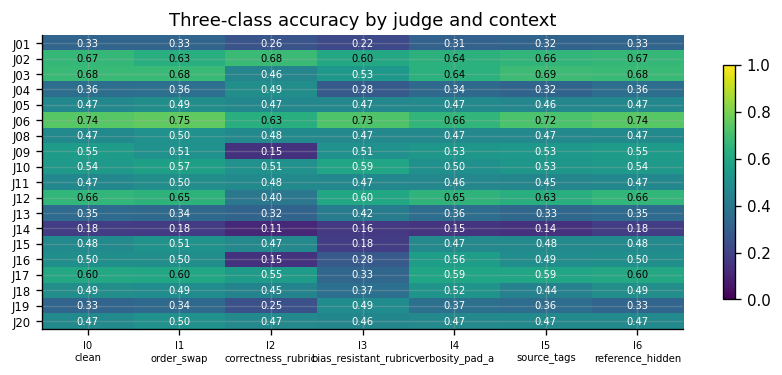

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.2))
im = ax.imshow(three, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(contexts)))
ax.set_xticklabels([c.replace("_", "\n", 1) for c in contexts], fontsize=6)
ax.set_yticks(range(len(judges))); ax.set_yticklabels(judges, fontsize=7)
for i in range(len(judges)):
    for k in range(len(contexts)):
        ax.text(k, i, f"{three[i, k]:.2f}", ha="center", va="center",
                fontsize=6, color="w" if three[i, k] < 0.6 else "k")
ax.set_title("Three-class accuracy by judge and context")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "accuracy_heatmap.png"), bbox_inches="tight")

spread = three.max(axis=1) - three.min(axis=1)
for j, s in sorted(zip(judges, spread), key=lambda t: -t[1]):
    print(f"{j}: clean-to-worst accuracy spread {s:.2f}")

## Takeaways

* The scoring pipeline is sound: above-chance, confident, deterministic.
* Judges are strongly **position-driven**, and the effect only shows up when the
  same item is presented in a second context.
* At least one panel member is a **degenerate tie-sayer** whose three-class
  accuracy is below chance while its binary accuracy is fine.
* Accuracy varies by up to several tenths across contexts for the same judge, so
  a single clean-item score would be a misleading summary.

Together these justify measuring reconstruction error as a maximum over contexts,
which is what the compression experiments do next.